In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import os

# FRED setup
fred_key = os.getenv('FRED_API_KEY')
fred = Fred(api_key=fred_key)

# 2020-2025 analysis
treasury_10y = fred.get_series('DGS10', '2020-01-01')
treasury_5y = fred.get_series('DGS5', '2020-01-01') 
aaa = fred.get_series('AAA', '2020-01-01')

# Cleaning monthly alignment
bond_df = pd.DataFrame({
    '10Y_Treasury': treasury_10y.resample('ME').mean(),
    '5Y_Treasury': treasury_5y.resample('ME').mean(),
    'AAA_Corporate': aaa.resample('ME').last()
}).dropna()


In [19]:
# 2020-2025 data
bond_df['AAA_Spread'] = bond_df['AAA_Corporate'] - bond_df['10Y_Treasury']
bond_df['Yield_Curve'] = bond_df['10Y_Treasury'] - bond_df['5Y_Treasury']

print("2020-2025 Spread Analysis:")
print(f"Current AAA Spread: {bond_df['AAA_Spread'].iloc[-1]:.3f}% ({bond_df['AAA_Spread'].iloc[-1]*100:.1f} bps)")
print(f"Average AAA Spread: {bond_df['AAA_Spread'].mean():.3f}%")
print(f"Current Yield Curve: {bond_df['Yield_Curve'].iloc[-1]:.3f}%")

2020-2025 Spread Analysis:
Current AAA Spread: 1.090% (109.0 bps)
Average AAA Spread: 1.118%
Current Yield Curve: 0.458%


In [21]:
#Percentile and Volatility Context
print("SPREAD CONTEXT ANALYSIS (2020-2025)")

current_aaa_spread = bond_df['AAA_Spread'].iloc[-1]
current_curve = bond_df['Yield_Curve'].iloc[-1]

# AAA Spread Analysis
aaa_percentile = (bond_df['AAA_Spread'] < current_aaa_spread).mean() * 100
print(f"AAA Spread: {current_aaa_spread:.3f}% ({current_aaa_spread*100:.1f} bps)")
print(f"• Percentile: {aaa_percentile:.1f}% (higher = wider spread)")
print(f"• Range: {bond_df['AAA_Spread'].min():.3f}% to {bond_df['AAA_Spread'].max():.3f}%")
print(f"• Volatility: {bond_df['AAA_Spread'].std():.3f}%")

# Yield Curve Analysis  
curve_percentile = (bond_df['Yield_Curve'] < current_curve).mean() * 100
print(f"\nYield Curve: {current_curve:.3f}% ({current_curve*100:.1f} bps)")
print(f"• Percentile: {curve_percentile:.1f}% (higher = steeper curve)")
print(f"• Range: {bond_df['Yield_Curve'].min():.3f}% to {bond_df['Yield_Curve'].max():.3f}%")

# Implications
print(f"\nIMPLICATIONS:")
if aaa_percentile > 70:
    print("• High spread environment → potentially higher funding costs")
elif aaa_percentile < 30:
    print("• Low spread environment → favorable funding conditions")
else:
    print("• Moderate spread environment → typical funding costs")

SPREAD CONTEXT ANALYSIS (2020-2025)
AAA Spread: 1.090% (109.0 bps)
• Percentile: 49.3% (higher = wider spread)
• Range: 0.720% to 2.150%
• Volatility: 0.301%

Yield Curve: 0.458% (45.8 bps)
• Percentile: 79.7% (higher = steeper curve)
• Range: -0.242% to 0.801%

IMPLICATIONS:
• Moderate spread environment → typical funding costs


In [1]:
print("LIMITATIONS & METHODOLOGICAL CONTEXT")

print("""
1. Temporal Scope Limitations
   • Analysis exclusively represents 2020-2025 
   • Percentiles reflect post-COVID monetary regime
   • The'49th percentile' denotes median of recent period 
   • Excludes pre-2020 market environments (ZGFC, 2008 crisis)

2. Proxy Data Limitations
   • AAA corporate yields approximate World Bank bond yields
   • WB bonds may carry development premium/discount vs corporates
   • Actual WB secondary market spread data has not been incorporated

3. Yield curve Interpretation
   • Observed inversion (-0.242%) represents 2022-2023 Fed tightening cycle
   • Current steep curve (80th percentile) indicates expected normalization of policy
   • Curve dynamics heavily influenced by recent monetary policy volatility

4. Volatility context
   • COVID-era market stress is captured by 30 bps spread volatility 
   • Pre-2020 volatility regimes not represented
   • Professional assessment would use rolling windows & regime analysis
""")

print("CONCLUSION: Analysis provides directional insight for")
print("current funding environment but should be supplemented")
print("with WB-specific pricing data for issuance decisions.")

LIMITATIONS & METHODOLOGICAL CONTEXT

1. Temporal Scope Limitations
   • Analysis exclusively represents 2020-2025 
   • Percentiles reflect post-COVID monetary regime
   • The'49th percentile' denotes median of recent period 
   • Excludes pre-2020 market environments (ZGFC, 2008 crisis)

2. Proxy Data Limitations
   • AAA corporate yields ≠ World Bank bond yields
   • WB bonds may carry development premium/discount vs corporates
   • Actual WB secondary market spread data has not been incorporated

3. Yield curve Interpretation
   • Observed inversion (-0.242%) represents 2022-2023 Fed tightening cycle
   • Current steep curve (80th percentile) indicates expected normalization of policy
   • Curve dynamics heavily influenced by recent monetary policy volatility

4. Volatility context
   • COVID-era market stress is captured by 30 bps spread volatility 
   • Pre-2020 volatility regimes not represented
   • Professional assessment would use rolling windows & regime analysis

CONCLUSION

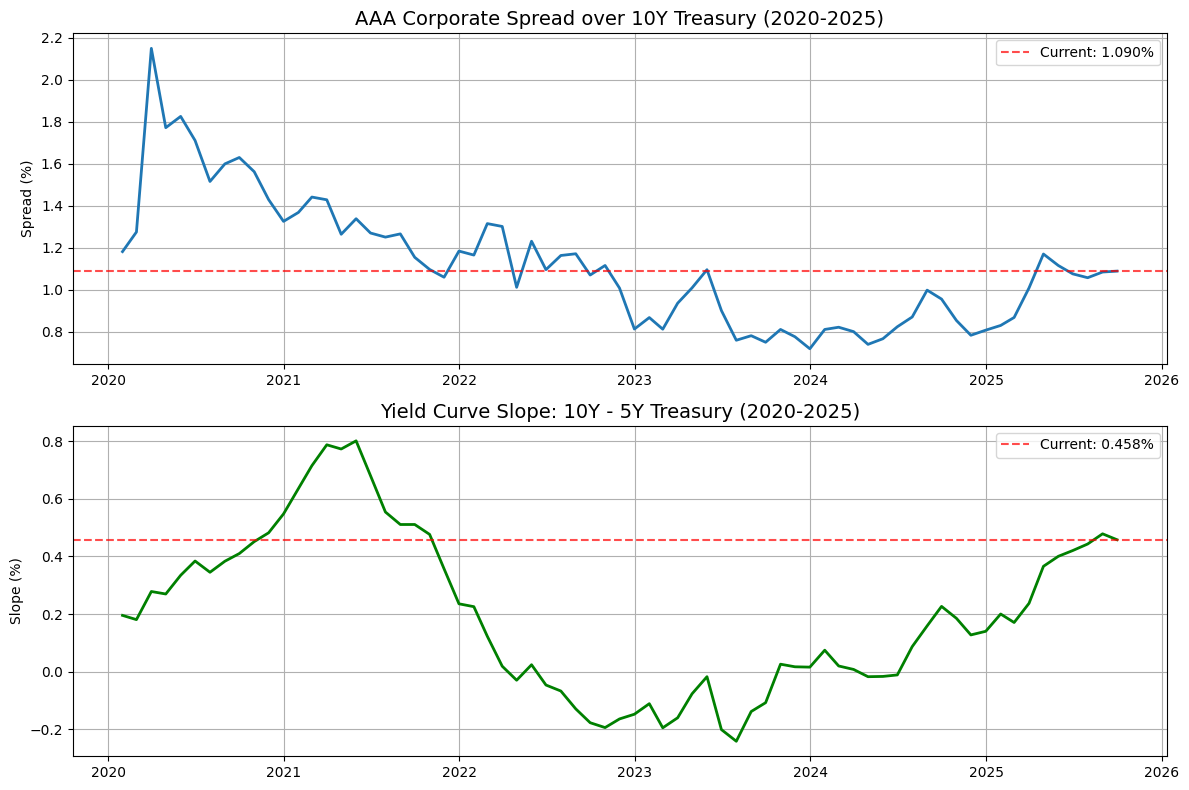

In [23]:
# Visualization 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# AAA Spread plot
ax1.plot(bond_df.index, bond_df['AAA_Spread'], linewidth=2)
ax1.axhline(y=current_aaa_spread, color='r', linestyle='--', alpha=0.7, label=f'Current: {current_aaa_spread:.3f}%')
ax1.set_title('AAA Corporate Spread over 10Y Treasury (2020-2025)', fontsize=14)
ax1.set_ylabel('Spread (%)')
ax1.legend()
ax1.grid(True)

# Yield Curve plot
ax2.plot(bond_df.index, bond_df['Yield_Curve'], linewidth=2, color='green')
ax2.axhline(y=current_curve, color='r', linestyle='--', alpha=0.7, label=f'Current: {current_curve:.3f}%')
ax2.set_title('Yield Curve Slope: 10Y - 5Y Treasury (2020-2025)', fontsize=14)
ax2.set_ylabel('Slope (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()